<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
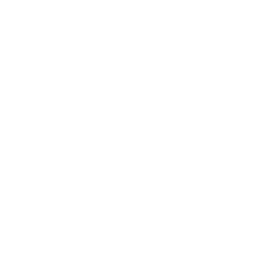
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Monitoraggio del Processo di Laminazione in Acciaieria</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; SPC multivariato per il controllo di spessore e qualità superficiale del laminatoio a caldo &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Sintesi

Un laminatoio a caldo per nastri lamina bramme di acciaio fino a
ottenere una bobina sottile. Sei segnali di processo correlati
(spessori, forza di laminazione, luce dei cilindri, corrente motore,
temperatura di uscita) si muovono insieme quando la linea è in buono
stato, quindi monitorarli un grafico alla volta non coglie gli
spostamenti congiunti che contano davvero. Questo esempio costruisce
una baseline multivariata con **PROC MVPMODEL** e poi fa scorrere 100
bobine di produzione attraverso **PROC MVPMONITOR**, che assegna a ogni
bobina un unico punteggio della statistica *T*&sup2; di Hotelling e lo
confronta con un limite di controllo.

Rispetto a un limite sotto controllo di *T*&sup2; = **17.13** (&alpha; =
0.05), **4 bobine su 100** segnalano una condizione fuori controllo —
le bobine **91, 92, 94 e 95**, esattamente la finestra in cui è stato
iniettato un episodio di vibrazione (chatter) del cilindro di supporto.
Il picco di *T*&sup2; raggiunge **21.91** alla bobina 95, circa
**1.3&times;** il limite. La graduale rampa di usura dei cilindri sulle
bobine successive innalza la *T*&sup2; di base ma resta sotto il limite
fino all'evento di chatter, cosicché il grafico separa nettamente la
deriva lenta dal guasto acuto che richiede attenzione immediata.


## Fonti dei dati

- **mill_baseline** — 50 bobine laminate durante un tratto noto come
  buono della campagna; usato per adattare il modello di riferimento
  multivariato (PCA).
- **mill_stream** — 100 bobine dalla linea live. Le bobine 1–55
  procedono sotto controllo; l'usura dei cilindri si sviluppa
  gradualmente sulle bobine 56–100; un episodio di vibrazione (chatter)
  del cilindro di supporto colpisce le bobine 91–95.
- **Variabili di processo** (6): `entry_thickness`, `exit_thickness`,
  `rolling_force`, `roll_gap`, `motor_current`, `exit_temp`.

> L'ambiente gira senza licenza, quindi i dataset sono limitati a 100
> osservazioni. Lo scenario è dimensionato per questo limite: il
> disturbo è collocato verso la fine di un flusso di 100 bobine anziché
> alla bobina 2.800 di 5.000.


---

### Passo 1 — Costruire il modello di riferimento multivariato

`PROC MVPMODEL` esegue un'analisi delle componenti principali delle sei
variabili di processo sulla baseline sotto controllo e scrive i
loadings, gli autovalori e la centratura/scalatura in `mill_model`.
Vengono mantenute tre componenti. Questo modello definisce come appare
la "normalità" come un'unica regione multivariata anziché sei
intervalli indipendenti.


In [1]:
DATI mill_baseline;
  CHIAMARE streaminit(66);
  FARE coil_id = 1 FINO_A 50;
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + rand('normal', 0, 0.030);
    rolling_force   = 18000 + rand('normal', 0, 150);
    roll_gap        =  2.85 + rand('normal', 0, 0.015);
    motor_current   =   850 + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    USCITA;
  FINE;
ESEGUIRE;

PROCEDURA mvpmodel DATI=mill_baseline outmodel=mill_model;
  VARIABILE entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  ncomp=3;
ESEGUIRE;



                    The MVPMODEL Procedure

  Data Set:          mill_baseline
  Number of Variables: 6
  Missing Value Handling: Exclude
  Number of Observations Read: 50
  Number of Observations Used: 50
  Number of Principal Components: 3

  Correlation Matrix
         entry_thicknessexit_thicknessrolling_force  roll_gapmotor_current exit_temp
  entry_thickness    1.0000   -0.0416   -0.1641   -0.1661    0.1555    0.0649
  exit_thickness   -0.0416    1.0000    0.0406    0.0029    0.0946   -0.1421
  rolling_force   -0.1641    0.0406    1.0000   -0.1351    0.2077   -0.0051
  roll_gap   -0.1661    0.0029   -0.1351    1.0000   -0.0510   -0.0876
  motor_current    0.1555    0.0946    0.2077   -0.0510    1.0000    0.1587
  exit_temp    0.0649   -0.1421   -0.0051   -0.0876    0.1587    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 1.37232115  0.14267284    0.2287    0.2287
    2 1.22964831  0.16747324    0.2049    0.4337
    3


NOTE: DATA mill_baseline


NOTE: Wrote mill_baseline (50 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


---

### Passo 2 — Far scorrere le bobine di produzione e assegnarne il punteggio

`PROC MVPMONITOR` proietta ciascuna delle 100 bobine di produzione sul
modello salvato e calcola la sua *T*&sup2; di Hotelling. La procedura
deriva il limite di controllo dalle dimensioni del modello e dal valore
predefinito &alpha; = 0.05, quindi segnala ogni bobina la cui *T*&sup2;
lo supera. I risultati, comprese le colonne `_TSQUARED`, `_LIMIT` e
`_SIGNAL`, vengono scritti in `mill_scores` con chiave `coil_id`.


In [2]:
DATI mill_stream;
  CHIAMARE streaminit(42);
  FARE coil_id = 1 FINO_A 100;
    /* la rampa di usura dei cilindri sale da 0 a 1 sulle bobine 56-100 */
    wear    = MAX(0, coil_id - 55) / 45;
    /* episodio di vibrazione (chatter) del cilindro di supporto sulle bobine 91-95 */
    chatter = (coil_id >= 91 E_LOG coil_id <= 95);
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + wear*0.10 + chatter*0.35
                            + rand('normal', 0, 0.030);
    rolling_force   = 18000 + wear*600  + chatter*1600
                            + rand('normal', 0, 150);
    roll_gap        =  2.85 + wear*0.055
                            + rand('normal', 0, 0.015);
    motor_current   =   850 + wear*38   + chatter*95
                            + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    RIMUOVERE wear chatter;
    USCITA;
  FINE;
ESEGUIRE;

PROCEDURA mvpmonitor DATI=mill_stream model=mill_model
                out=mill_scores;
  VARIABILE entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  id coil_id;
ESEGUIRE;



                    The MVPMONITOR Procedure

  Variables:       6
  Observations:    100
  T2 Limit:        17.1334
  Signals:         4





NOTE: DATA mill_stream


NOTE: Wrote mill_stream (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMONITOR
NOTE: PROC MVPMONITOR statement used.


Il riepilogo della procedura riporta il limite di controllo e il
conteggio dei segnali. Di seguito, l'estratto stampato attorno al
disturbo mostra che le bobine della baseline restano ben al di sotto del
limite, mentre la finestra di chatter porta quattro bobine al di sopra
di esso.


In [3]:
/* Contrassegna le bobine fuori controllo e cattura il T2 di allarme per il grafico */
DATI mill_scores;
  IMPOSTARE mill_scores;
  SE_COND _SIGNAL = 1 ALLORA t2_alarm = _TSQUARED;
  ALTRIMENTI t2_alarm = .;
ESEGUIRE;

PROCEDURA STAMPARE DATI=mill_scores(firstobs=88 obs=96) noobs ETICHETTA;
  VARIABILE coil_id _TSQUARED _LIMIT _SIGNAL;
  ETICHETTA coil_id='ID Bobina' _TSQUARED='T-quadrato' _LIMIT='Limite' _SIGNAL='Segnale';
  TITOLO 'Punteggi T2 nella finestra di chatter (bobine 88-96)';
ESEGUIRE;


                                  Punteggi T2 nella finestra di chatter (bobine 88-96)                                  

ID Bobina  T-quadrato     Limite  Segnale
       88    9.983151  17.133408        0
       89    2.915646  17.133408        0
       90     7.80613  17.133408        0
       91   18.813814  17.133408        1
       92   18.249361  17.133408        1
       93   16.638221  17.133408        0
       94   17.981792  17.133408        1
       95   21.912329  17.133408        1
       96    5.118574  17.133408        0

... 4 more observations (showing 9 of 13)




NOTE: DATA mill_scores


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_scores (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=mill_scores

NOTE: PROC PRINT completed: 9 observations printed, 4 variables


---

### Passo 3 — Grafico di controllo multivariato

Il grafico sovrappone la *T*&sup2; per bobina al proprio limite di
controllo. Le bobine fuori controllo sono evidenziate in rosso; il
marcatore verticale tratteggiato segnala l'inizio dell'episodio di
chatter. La lenta risalita verso destra è l'usura dei cilindri che
innalza la baseline; i quattro punti rossi sono il guasto acuto di
chatter.


                                  Punteggi T2 nella finestra di chatter (bobine 88-96)                                  




NOTE: PROC SGPLOT data=mill_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


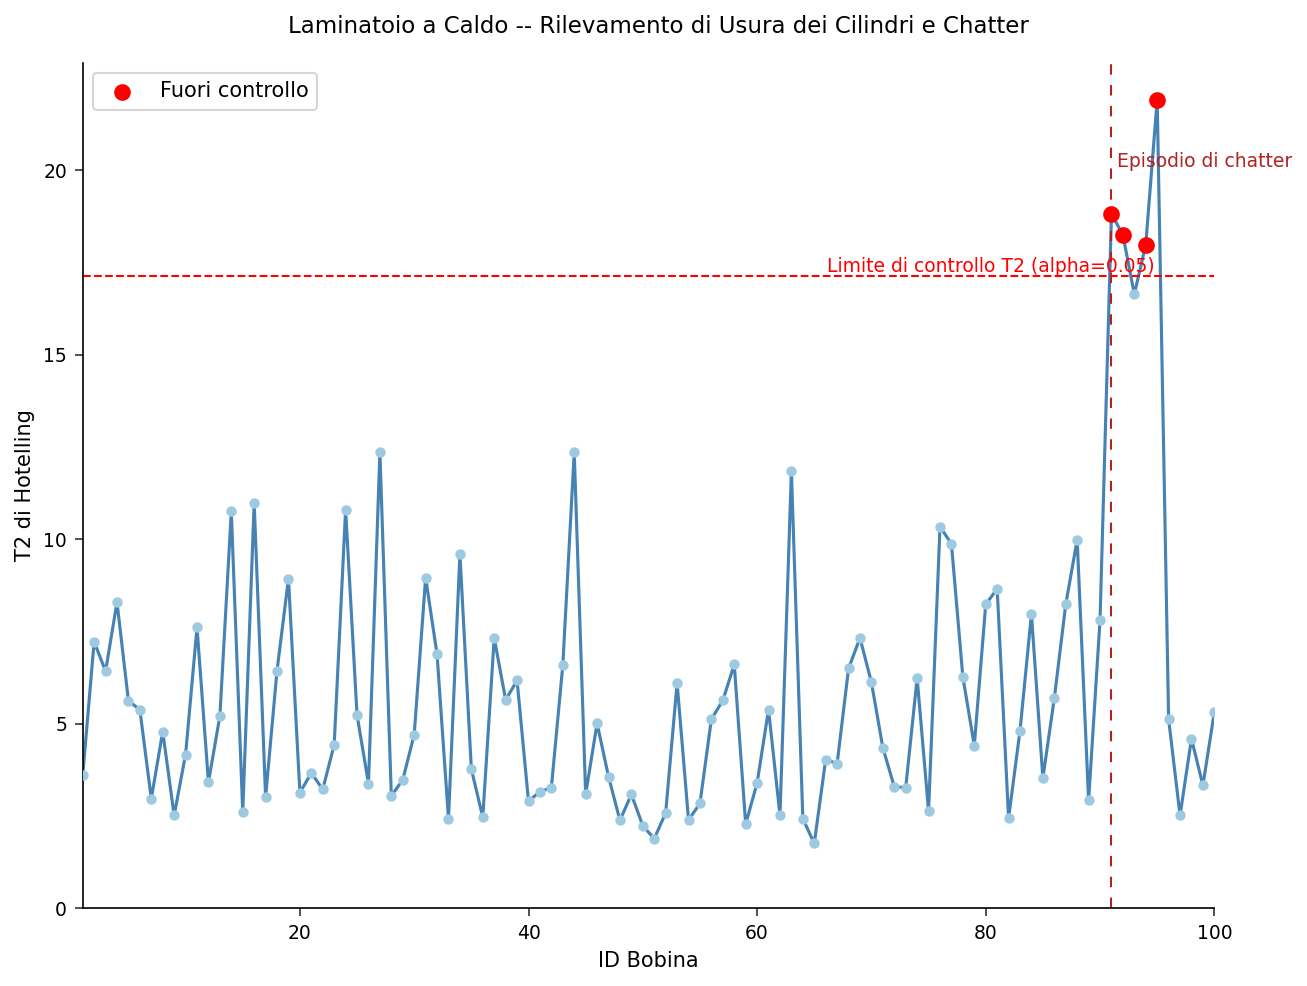

In [4]:
PROCEDURA SGPLOT DATI=mill_scores;
  SERIES  x=coil_id y=_TSQUARED /
          LINEATTRS=(color=steelblue thickness=1.5);
  SCATTER x=coil_id y=_TSQUARED /
          MARKERATTRS=(SYMBOL=circlefilled size=4 color=cx9ecae1);
  SCATTER x=coil_id y=t2_alarm /
          MARKERATTRS=(SYMBOL=circlefilled size=7 color=red)
          legendlabel='Fuori controllo';
  REFLINE _LIMIT / AXIS=y
          ETICHETTA='Limite di controllo T2 (alpha=0.05)'
          LINEATTRS=(color=red pattern=dash);
  REFLINE 91 / AXIS=x ETICHETTA='Episodio di chatter'
          LINEATTRS=(color=firebrick pattern=shortdash);
  XAXIS ETICHETTA='ID Bobina' MIN=1 MAX=100;
  YAXIS ETICHETTA="T2 di Hotelling" MIN=0;
  TITOLO 'Laminatoio a Caldo -- Rilevamento di Usura dei Cilindri e Chatter';
ESEGUIRE;


---

### Passo 4 — Quantificare le bobine fuori controllo

Le bobine fuori controllo vengono instradate verso un dataset separato
per l'ufficio qualità. `PROC MEANS` confronta il livello di *T*&sup2;
delle bobine segnalate con quello della popolazione sotto controllo, e
le bobine segnalate vengono esportate per l'instradamento a valle verso
scarto/rilavorazione.


In [5]:
DATI mill_ooc;
  IMPOSTARE mill_scores;
  SE_COND _SIGNAL = 1;
ESEGUIRE;

PROCEDURA MEDIE DATI=mill_scores n mean MAX maxdec=2;
  CLASSE _SIGNAL;
  VARIABILE _TSQUARED;
  ETICHETTA _SIGNAL='Segnale' _TSQUARED='T-quadrato';
  TITOLO 'T2 per stato di controllo (0 = sotto controllo, 1 = segnale)';
ESEGUIRE;

PROCEDURA STAMPARE DATI=mill_ooc noobs ETICHETTA;
  VARIABILE coil_id _TSQUARED _LIMIT;
  ETICHETTA coil_id='ID Bobina' _TSQUARED='T-quadrato' _LIMIT='Limite';
  TITOLO 'Bobine fuori controllo segnalate per ispezione';
ESEGUIRE;

PROCEDURA EXPORT DATI=mill_ooc
            OUTFILE='steel_mill_ooc_coils.csv'
            DBMS=csv REPLACE;
ESEGUIRE;


                              T2 per stato di controllo (0 = sotto controllo, 1 = segnale)                              

                                                  The MEANS Procedure

                                        Analysis Variable : _TSQUARED T-quadrato

        Segnale           N Obs           Mean        Maximum
        -----------------------------------------------------
        0                    96           5.39          16.64
        1                     4          19.24          21.91
        -----------------------------------------------------

                                     Bobine fuori controllo segnalate per ispezione                                     

ID Bobina  T-quadrato     Limite
       91   18.813814  17.133408
       92   18.249361  17.133408
       94   17.981792  17.133408
       95   21.912329  17.133408




NOTE: DATA mill_ooc


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_ooc (4 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=mill_ooc

NOTE: PROC PRINT completed: 4 observations printed, 3 variables
NOTE: PROC EXPORT data=mill_ooc outfile=steel_mill_ooc_coils.csv

NOTE: Exported 4 rows to steel_mill_ooc_coils.csv.


## Risultati

- **Bobine monitorate**: 100; **limite di controllo** *T*&sup2; =
  **17.13** (&alpha; = 0.05).
- **Bobine fuori controllo**: **4** — bobine **91, 92, 94, 95**, tutte
  all'interno della finestra di chatter iniettata (91–95). La bobina 93
  raggiunge un picco di *T*&sup2; = 16.64, appena sotto il limite.
- **Severità di picco**: *T*&sup2; = **21.91** alla bobina 95 (circa
  1.3&times; il limite); le bobine sotto controllo hanno una *T*&sup2;
  media &asymp; **5.4**.
- **Usura vs. guasto**: la graduale rampa di usura dei cilindri innalza
  la baseline delle bobine successive ma non supera mai da sola il
  limite, cosicché l'unico grafico multivariato distingue la deriva
  lenta (da osservare) dall'evento acuto di chatter (da correggere).
- **Azione**: le quattro bobine segnalate vengono esportate in
  `steel_mill_ooc_coils.csv` per l'ispezione e l'instradamento verso
  scarto/rilavorazione; la firma di chatter indica il cuscinetto del
  cilindro di supporto da ispezionare prima della prossima campagna.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Riservato
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Realizzato con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>